# Slice Selection with a z-Gradient in MRI

To excite a single axial **slice**, MRI applies a magnetic-field **gradient along z** during the RF
pulse. The gradient makes the field — and therefore the Larmor frequency — depend on position:
$$B(z) = B_0 + G_z\, z, \qquad f(z) = \frac{\gamma}{2\pi}\,\big(B_0 + G_z z\big).$$

Because each $z$ now resonates at a unique frequency, exciting a **band of frequencies**
$[f_0-\tfrac{BW}{2},\, f_0+\tfrac{BW}{2}]$ excites exactly the slab of tissue whose $f(z)$ falls in
that band. The RF waveform that produces a rectangular frequency band is a **sinc** in time — a
Fourier-transform pair. This notebook visualizes:
1. the linear $f(z)$ mapping and the selected slice,
2. the rectangular frequency band (spectral / k-space view),
3. the time-domain sinc RF pulse, and
4. an FFT check mapping the RF spectrum back to the excited slice in $z$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Parameters and the slice-selection relations
The needed RF **bandwidth** for a slice of thickness $\Delta z$ under gradient $G_z$ is
$$BW = \frac{\gamma}{2\pi}\,G_z\,\Delta z, \qquad\Rightarrow\qquad \Delta z = \frac{BW}{(\gamma/2\pi)\,G_z},$$
and the slice **position** is set by the center frequency $f_0 = \frac{\gamma}{2\pi}(B_0+G_z z_0)$.

In [2]:
gamma_bar = 42.577e6      # proton gyromagnetic ratio / 2pi [Hz/T]
B0  = 1.5                 # static field [T]
Gz  = 10e-3               # z-gradient strength [T/m]  (10 mT/m)
z0  = 0.0                 # slice center [m]
dz  = 5e-3                # slice thickness [m]  (5 mm)

# Position-dependent Larmor frequency
z   = np.linspace(-0.10, 0.10, 1000)   # +/- 100 mm
f_z = gamma_bar * (B0 + Gz * z)

f0 = gamma_bar * (B0 + Gz * z0)        # center (resonance) frequency of the slice
BW = gamma_bar * Gz * dz               # RF bandwidth needed to excite the slice
f_lo, f_hi = f0 - BW / 2, f0 + BW / 2
z_lo, z_hi = z0 - dz / 2, z0 + dz / 2

print(f"center frequency f0 = {f0/1e6:.4f} MHz")
print(f"slice bandwidth  BW = {BW:.1f} Hz")
print(f"slice edges: z in [{z_lo*1e3:.1f}, {z_hi*1e3:.1f}] mm")
print(f"            f in [{f_lo/1e6:.6f}, {f_hi/1e6:.6f}] MHz")
print(f"thickness check: dz = BW/(gamma_bar*Gz) = {BW/(gamma_bar*Gz)*1e3:.2f} mm")

center frequency f0 = 63.8655 MHz
slice bandwidth  BW = 2128.8 Hz
slice edges: z in [-2.5, 2.5] mm
            f in [63.864436, 63.866564] MHz
thickness check: dz = BW/(gamma_bar*Gz) = 5.00 mm


## 1. The gradient maps position $z$ to frequency $f(z)$
The selected slice (shaded) is the range of $z$ whose Larmor frequency lies inside the excitation
band $[f_0-BW/2,\,f_0+BW/2]$.

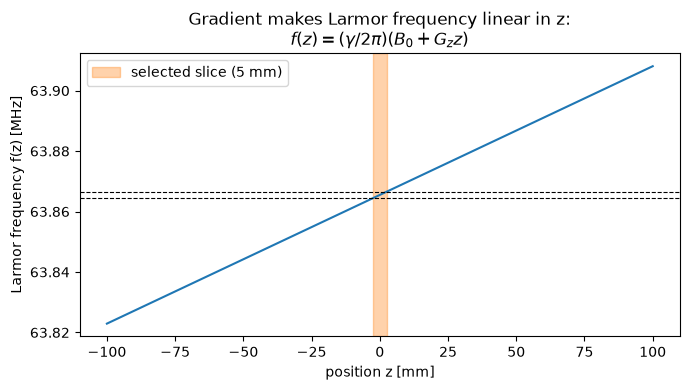

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(z * 1e3, f_z / 1e6, color="tab:blue")
ax.axvspan(z_lo * 1e3, z_hi * 1e3, color="tab:orange", alpha=0.35,
           label=f"selected slice ({dz*1e3:.0f} mm)")
ax.axhline(f_lo / 1e6, color="k", ls="--", lw=0.8)
ax.axhline(f_hi / 1e6, color="k", ls="--", lw=0.8)
ax.set_xlabel("position z [mm]")
ax.set_ylabel("Larmor frequency f(z) [MHz]")
ax.set_title("Gradient makes Larmor frequency linear in z:\n"
             r"$f(z) = (\gamma/2\pi)(B_0 + G_z z)$")
ax.legend()
plt.tight_layout()
plt.show()

## 2. Frequency-domain slice profile (the excitation band)
The ideal excitation is a **rectangular band** of width $BW$ centered at $f_0$. Via the gradient, a
frequency offset $\Delta f$ corresponds to a position offset $\Delta z = \Delta f/[(\gamma/2\pi)G_z]$
(top axis).

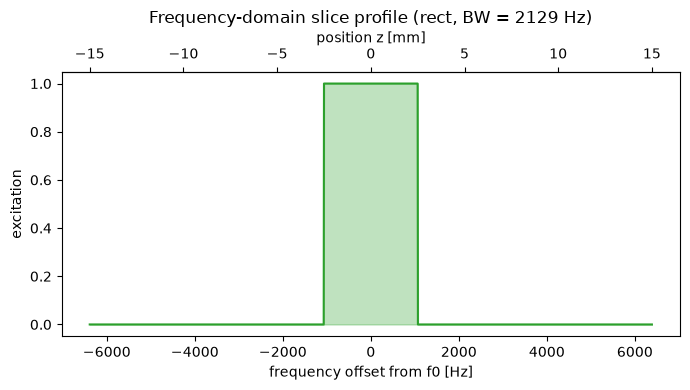

In [4]:
f_axis  = np.linspace(f0 - 3 * BW, f0 + 3 * BW, 2000)
profile = ((f_axis >= f_lo) & (f_axis <= f_hi)).astype(float)
df      = f_axis - f0

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(df, profile, color="tab:green")
ax.fill_between(df, profile, color="tab:green", alpha=0.3)
ax.set_xlabel("frequency offset from f0 [Hz]")
ax.set_ylabel("excitation")
ax.set_title(f"Frequency-domain slice profile (rect, BW = {BW:.0f} Hz)")

secax = ax.secondary_xaxis(
    "top",
    functions=(lambda d: d / (gamma_bar * Gz) * 1e3 + z0 * 1e3,
               lambda zz: (zz / 1e3 - z0) * (gamma_bar * Gz)))
secax.set_xlabel("position z [mm]")
plt.tight_layout()
plt.show()

## 3. Time-domain RF pulse (the sinc)
The RF envelope that produces a rectangular frequency band is its inverse Fourier transform, a
**sinc** of the form $\text{sinc}(BW\cdot t)$. A finite pulse is windowed (apodized) to limit
truncation ripple. Below: the envelope, and a zoom of the actual modulated $B_1(t)$ waveform (shown
at a reduced demonstration carrier since the true $f_0\approx 64$ MHz is too fast to draw).

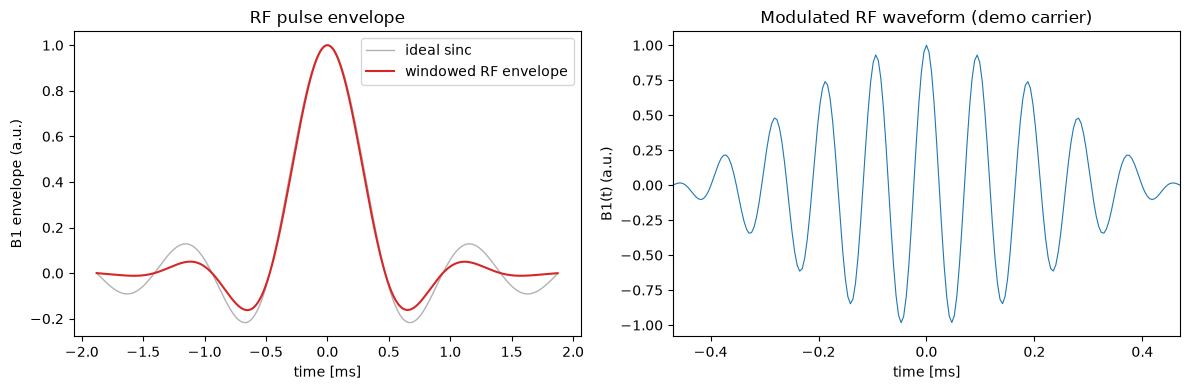

In [5]:
fs   = 100 * BW               # sampling rate [Hz]
T_rf = 8 / BW                 # pulse duration [s]  (several sinc lobes)
n    = int(T_rf * fs)
t    = (np.arange(n) - n // 2) / fs    # centered time axis [s]

env    = np.sinc(BW * t)               # np.sinc(x)=sin(pi x)/(pi x); its FT is a rect of width BW
window = np.hamming(n)                 # apodization
env_w  = env * window

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(t * 1e3, env, color="tab:gray", lw=1, alpha=0.6, label="ideal sinc")
ax[0].plot(t * 1e3, env_w, color="tab:red", lw=1.5, label="windowed RF envelope")
ax[0].set_xlabel("time [ms]"); ax[0].set_ylabel("B1 envelope (a.u.)")
ax[0].set_title("RF pulse envelope"); ax[0].legend()

f_demo = 5 * BW                        # demonstration carrier (real carrier is f0)
rf = env_w * np.cos(2 * np.pi * f_demo * t)
ax[1].plot(t * 1e3, rf, color="tab:blue", lw=0.8)
ax[1].set_xlim(-1e3 / BW, 1e3 / BW)    # zoom to central lobes
ax[1].set_xlabel("time [ms]"); ax[1].set_ylabel("B1(t) (a.u.)")
ax[1].set_title("Modulated RF waveform (demo carrier)")
plt.tight_layout()
plt.show()

## 4. Verify: FFT of the RF pulse → rect band → excited slice in z
Taking the FFT of the time-domain sinc recovers the rectangular frequency band, which maps through
the gradient to the selected slab in $z$.

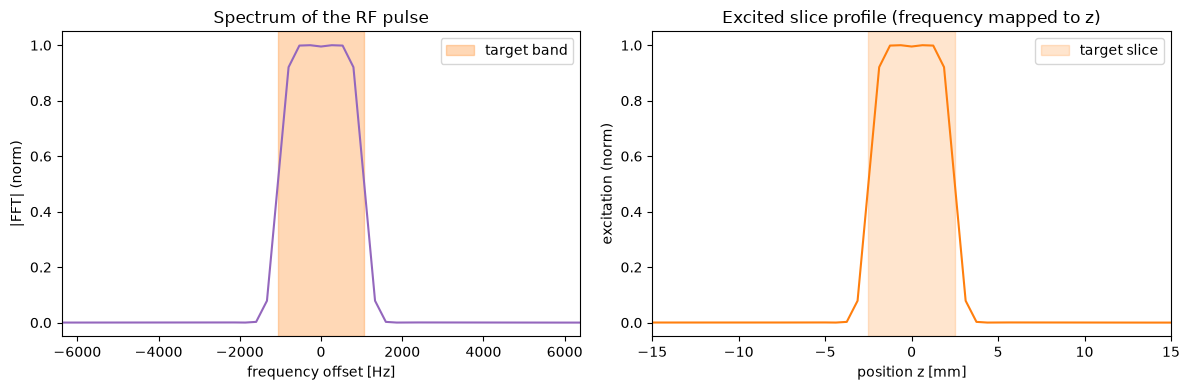

In [6]:
spec  = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(env_w)))
freqs = np.fft.fftshift(np.fft.fftfreq(n, 1 / fs))
mag   = np.abs(spec)
mag  /= mag.max()

z_from_f = freqs / (gamma_bar * Gz) * 1e3 + z0 * 1e3    # baseband freq -> z [mm]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(freqs, mag, color="tab:purple")
ax[0].axvspan(-BW / 2, BW / 2, color="tab:orange", alpha=0.3, label="target band")
ax[0].set_xlim(-3 * BW, 3 * BW)
ax[0].set_xlabel("frequency offset [Hz]"); ax[0].set_ylabel("|FFT| (norm)")
ax[0].set_title("Spectrum of the RF pulse"); ax[0].legend()

ax[1].plot(z_from_f, mag, color="tab:orange")
ax[1].axvspan(z_lo * 1e3, z_hi * 1e3, color="tab:orange", alpha=0.2, label="target slice")
ax[1].set_xlim((z0 - 3 * dz) * 1e3, (z0 + 3 * dz) * 1e3)
ax[1].set_xlabel("position z [mm]"); ax[1].set_ylabel("excitation (norm)")
ax[1].set_title("Excited slice profile (frequency mapped to z)"); ax[1].legend()
plt.tight_layout()
plt.show()

## Takeaways
- A **z-gradient** $G_z$ turns position into frequency: $f(z)=(\gamma/2\pi)(B_0+G_z z)$.
- Exciting a **rectangular frequency band** of width $BW$ selects a slab of thickness
  $\Delta z = BW/[(\gamma/2\pi)G_z]$; the center frequency $f_0$ sets the slice position.
- The RF waveform for a rect band is a **sinc** in time (a Fourier pair); windowing trades slice-
  profile sharpness against pulse length.
- **Thinner slices** need a smaller $BW$ (longer sinc) or a **stronger gradient** $G_z$.